In [1]:
import numpy as np

In [15]:
import sys

In [2]:
import pandas as pd

In [3]:
df= pd.read_csv('placement.csv')

In [4]:
df = df.iloc[:,1:]

In [5]:
df.head()

,cgpa,iq,placement
0,6.8,123.0,1
1,5.9,106.0,0
2,5.3,121.0,0
3,7.4,132.0,1
4,5.8,142.0,0


In [6]:
import matplotlib.pyplot as plt

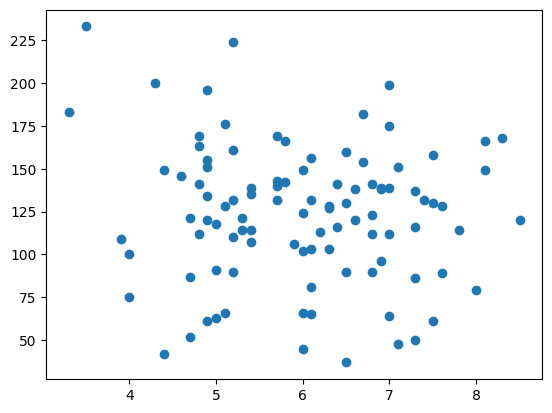

In [7]:
plt.scatter(df['cgpa'],df['iq'])

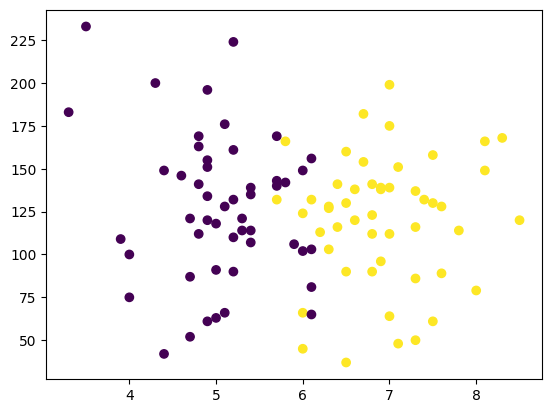

In [8]:
plt.scatter(df['cgpa'],df['iq'],c=df['placement'])

In [9]:
x = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [10]:
x

,cgpa,iq
0,6.8,123.0
1,5.9,106.0
2,5.3,121.0
3,7.4,132.0
4,5.8,142.0
...,...,...
95,4.3,200.0
96,4.4,42.0
97,6.7,182.0
98,6.3,103.0


In [11]:
y

0     1
1     0
2     0
3     1
4     0
     ..
95    0
96    0
97    1
98    1
99    1
Name: placement, Length: 100, dtype: int64

In [16]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.1)

In [18]:
x_train

,cgpa,iq
65,8.1,166.0
82,6.5,37.0
33,6.0,149.0
12,5.4,139.0
90,7.3,86.0
...,...,...
47,5.2,161.0
96,4.4,42.0
77,7.3,50.0
92,5.2,110.0


In [19]:
y_train

65    1
82    1
33    0
12    0
90    1
     ..
47    0
96    0
77    1
92    0
54    1
Name: placement, Length: 90, dtype: int64

In [20]:
x_test

,cgpa,iq
99,6.2,113.0
70,6.3,127.0
72,7.3,116.0
50,3.5,233.0
75,4.8,169.0
58,8.0,79.0
2,5.3,121.0
16,5.2,224.0
10,6.0,45.0
79,6.5,90.0


In [21]:
y_test

99    1
70    1
72    1
50    0
75    0
58    1
2     0
16    0
10    1
79    1
Name: placement, dtype: int64

In [22]:
from sklearn.preprocessing import StandardScaler


In [23]:
scaler = StandardScaler()

In [24]:
x_train = scaler.fit_transform(x_train)

In [25]:
x_train

array([[ 1.86100800e+00,  1.16578371e+00],
       [ 4.43097143e-01, -2.30555481e+00],
       [ 7.87098641e-16,  7.08320495e-01],
       [-5.31716572e-01,  4.39224486e-01],
       [ 1.15205257e+00, -9.86984362e-01],
       [-2.65858286e-01,  5.46862889e-01],
       [ 2.65858286e-01, -5.29521147e-01],
       [ 6.20336001e-01,  1.59633732e+00],
       [-2.65858286e-01,  1.24651251e+00],
       [ 1.24067200e+00,  2.50857280e-01],
       [ 4.43097143e-01,  1.00432610e+00],
       [-7.08955430e-01, -8.79345958e-01],
       [ 8.86194287e-02,  2.50857280e-01],
       [ 2.21548572e+00, -7.20579313e-02],
       [-9.74813716e-01,  1.97307174e+00],
       [-9.74813716e-01,  7.62139697e-01],
       [-9.74813716e-01, -1.65972438e+00],
       [ 8.86194287e-01,  4.39224486e-01],
       [-1.24067200e+00,  6.27591692e-01],
       [ 8.86194287e-01, -2.87334738e-01],
       [-8.86194287e-01, -1.60590518e+00],
       [ 1.59514972e+00, -2.33515537e-01],
       [-2.39272457e+00,  1.62324693e+00],
       [ 8.

In [26]:
x_test = scaler.transform(x_test)

In [27]:
x_test

array([[ 1.77238857e-01, -2.60425138e-01],
       [ 2.65858286e-01,  1.16309275e-01],
       [ 1.15205257e+00, -1.79696335e-01],
       [-2.21548572e+00,  2.96872697e+00],
       [-1.06343314e+00,  1.24651251e+00],
       [ 1.77238857e+00, -1.17535157e+00],
       [-6.20336001e-01, -4.51483304e-02],
       [-7.08955430e-01,  2.72654056e+00],
       [ 7.87098641e-16, -2.09027800e+00],
       [ 4.43097143e-01, -8.79345958e-01]])

In [28]:
from sklearn.linear_model import LogisticRegression

In [29]:
clf = LogisticRegression()

In [30]:
clf.fit(x_train,y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [33]:
y_pred = clf.predict(x_test)

In [32]:
y_test

99    1
70    1
72    1
50    0
75    0
58    1
2     0
16    0
10    1
79    1
Name: placement, dtype: int64

In [34]:
from sklearn.metrics import accuracy_score

In [35]:
accuracy_score(y_test,y_pred)

0.9

In [36]:
from mlxtend.plotting import plot_decision_regions

<Axes: >

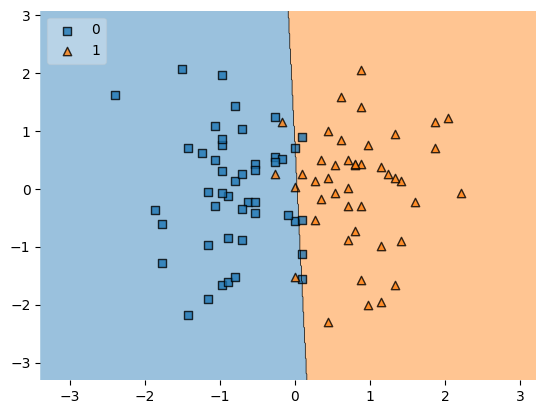

In [43]:
plot_decision_regions(x_train, y_train.values, clf=clf, legend=2)

In [40]:
import pickle

In [41]:
pickle.dump(clf,open('model.pkl','wb'))